# HLN MICA Tutorial

## 1.Introduction dependency

In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score

from MICA.preprocess import clr_normalize_each_cell, construct_neighbor_graph, fix_seed, pca
from MICA.MICA_pyG import Train_MICA
from MICA.utils import clustering

=== 正在使用MICA模型===


## 2.Parameter configuration

In [2]:
# =========================
# User configuration
# =========================
DATA_DIR = "/root/shared-nvme/Human_Lymph_Nodes/A1"
RNA_FILE = "adata_RNA.h5ad"
ADT_FILE = "adata_ADT.h5ad"

DATA_TYPE = "10x"
RANDOM_SEED = 2022
DIM_OUTPUT = 64
FUSION_BETA = 0.5
CLUSTER_METHOD = "mclust" 
USE_PCA_FOR_CLUSTERING = True

POINT_SIZE_UMAP = 40
POINT_SIZE_SPATIAL = 50
UMAP_N_NEIGHBORS = 10

os.environ["R_HOME"] = "/root/.conda/envs/MICA/lib/R"
import rpy2.robjects as robjects
robjects.r("print('R is working')")  

[1] "R is working"


'R is working'


## 3.Defining auxiliary function

In [3]:
def create_spatial_coords(adata: sc.AnnData) -> sc.AnnData:
    """Ensure adata.obsm['spatial'] exists."""
    if "spatial" in adata.obsm:
        return adata

    coord_keys = ["array_row", "array_col"]
    if not all(key in adata.obs.columns for key in coord_keys):
        raise ValueError(
            "Could not find spatial coordinates. Expected either adata.obsm['spatial'] "
            "or adata.obs columns ['array_row', 'array_col']."
        )

    coords = np.column_stack(
        [
            adata.obs["array_col"].values,
            adata.obs["array_row"].values,
        ]
    )
    adata.obsm["spatial"] = coords
    return adata


def load_ground_truth(adata_rna: sc.AnnData, adata_adt: sc.AnnData):
    """Try to find a usable ground-truth label column from RNA or ADT."""
    candidate_keys = [
        "Spatial_Label",
        "Spatial_label",
        "ground_truth",
        "Ground_Truth",
    ]

    for key in candidate_keys:
        if key in adata_rna.obs.columns:
            return key, adata_rna.obs[key].copy()
        if key in adata_adt.obs.columns:
            return key, adata_adt.obs[key].copy()

    return None, None


def preprocess_rna(adata_rna: sc.AnnData, target_dim: int, n_top_genes: int = 3000) -> sc.AnnData:
    """Preprocess RNA and store low-dimensional features in adata.obsm['feat']."""
    adata_rna = adata_rna.copy()
    sc.pp.filter_genes(adata_rna, min_cells=10)
    sc.pp.highly_variable_genes(adata_rna, flavor="seurat_v3", n_top_genes=n_top_genes)
    sc.pp.normalize_total(adata_rna, target_sum=1e4)
    sc.pp.log1p(adata_rna)
    sc.pp.scale(adata_rna)

    adata_rna_high = adata_rna[:, adata_rna.var["highly_variable"]].copy()
    n_comps = min(target_dim, adata_rna_high.n_vars, adata_rna_high.n_obs - 1)
    adata_rna.obsm["feat"] = pca(adata_rna_high, n_comps=n_comps)
    return adata_rna


def preprocess_adt(adata_adt: sc.AnnData) -> sc.AnnData:
    """Preprocess ADT and store low-dimensional features in adata.obsm['feat']."""
    adata_adt = adata_adt.copy()
    adata_adt = clr_normalize_each_cell(adata_adt)
    sc.pp.scale(adata_adt)

    n_comps = min(max(1, adata_adt.n_vars - 1), adata_adt.n_vars, adata_adt.n_obs - 1)
    adata_adt.obsm["feat"] = pca(adata_adt, n_comps=n_comps)
    return adata_adt


def align_feature_dims(adata_rna: sc.AnnData, adata_adt: sc.AnnData):
    """Force RNA / ADT feature dimensions to the same shared size."""
    rna_dim = adata_rna.obsm["feat"].shape[1]
    adt_dim = adata_adt.obsm["feat"].shape[1]
    shared_dim = min(rna_dim, adt_dim)

    adata_rna.obsm["feat"] = adata_rna.obsm["feat"][:, :shared_dim]
    adata_adt.obsm["feat"] = adata_adt.obsm["feat"][:, :shared_dim]
    return adata_rna, adata_adt, shared_dim


def to_numeric_labels(label_series: pd.Series) -> pd.Series:
    """Convert categorical / string labels to integer codes for metric computation."""
    if str(label_series.dtype) == "category" or label_series.dtype == object:
        categories = pd.Categorical(label_series)
        return pd.Series(categories.codes, index=label_series.index)
    return pd.Series(label_series.astype(int), index=label_series.index)


def evaluate_ari(true_labels: pd.Series, pred_labels: pd.Series) -> float:
    """Compute ARI for a single run."""
    common_idx = true_labels.index.intersection(pred_labels.index)
    y_true = to_numeric_labels(true_labels.loc[common_idx]).values
    y_pred = to_numeric_labels(pred_labels.loc[common_idx]).values
    return adjusted_rand_score(y_true, y_pred)


def plot_results(adata_plot: sc.AnnData, ari_score: float = None):
    """Visualize only MICA UMAP and spatial domains, with optional ARI in the title."""
    sc.pp.neighbors(adata_plot, use_rep="MICA", n_neighbors=UMAP_N_NEIGHBORS)
    sc.tl.umap(adata_plot)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    umap_title = "MICA"
    spatial_title = f"MICA--ARI:{ari_score:.4f}" if ari_score is not None else "MICA"

    sc.pl.umap(
        adata_plot,
        color="MICA_cluster",
        ax=axes[0],
        title=umap_title,
        s=POINT_SIZE_UMAP,
        show=False,
    )
    sc.pl.embedding(
        adata_plot,
        basis="spatial",
        color="MICA_cluster",
        ax=axes[1],
        title=spatial_title,
        s=POINT_SIZE_SPATIAL,
        show=False,
    )
    plt.tight_layout()
    plt.show()

In [4]:
warnings.filterwarnings("ignore", category=FutureWarning)
start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Data directory: {DATA_DIR}")
print(f"Data type: {DATA_TYPE}")
print(f"Clustering method: {CLUSTER_METHOD}")

fix_seed(RANDOM_SEED)

Using device: cuda
Data directory: /root/shared-nvme/Human_Lymph_Nodes/A1
Data type: 10x
Clustering method: mclust


In [5]:
adata_rna = sc.read_h5ad(os.path.join(DATA_DIR, RNA_FILE))
adata_adt = sc.read_h5ad(os.path.join(DATA_DIR, ADT_FILE))

adata_rna.var_names_make_unique()
adata_adt.var_names_make_unique()

print(f"RNA shape: {adata_rna.shape}")
print(f"ADT shape: {adata_adt.shape}")

adata_rna = create_spatial_coords(adata_rna)
adata_adt = create_spatial_coords(adata_adt)

gt_key, ground_truth = load_ground_truth(adata_rna, adata_adt)
if ground_truth is not None:
    print(f"Found ground-truth labels: {gt_key}")
    n_clusters = len(pd.Series(ground_truth).astype(str).unique())
else:
    print("No ground-truth labels found. ARI evaluation will be skipped.")
    n_clusters = 10

print(f"Target cluster number: {n_clusters}")

target_dim = max(1, adata_adt.n_vars - 1)

print("[1/2] Preprocessing RNA ...")
adata_rna = preprocess_rna(adata_rna, target_dim=target_dim)

print("[2/2] Preprocessing ADT ...")
adata_adt = preprocess_adt(adata_adt)

adata_rna, adata_adt, shared_dim = align_feature_dims(adata_rna, adata_adt)
print(f"Shared feature dimension: {shared_dim}")

/root/.conda/envs/MICA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/root/.conda/envs/MICA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


RNA shape: (3484, 18085)
ADT shape: (3484, 31)
Found ground-truth labels: Spatial_Label
Target cluster number: 10
[1/2] Preprocessing RNA ...
[2/2] Preprocessing ADT ...
Shared feature dimension: 30


In [6]:
data = construct_neighbor_graph(
    adata_omics1=adata_rna,
    adata_omics2=adata_adt,
    datatype=DATA_TYPE,
)

print("Graph construction finished.")

Graph construction finished.


In [7]:
model = Train_MICA(
    data=data,
    datatype=DATA_TYPE,
    device=device,
    random_seed=RANDOM_SEED,
    dim_input=shared_dim,
    dim_output=DIM_OUTPUT,
    fusion_beta=FUSION_BETA,
)

output = model.train()
print("Single-run training finished.")

/root/MICA/MICA/preprocess.py:197: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:641.)
  return torch.sparse.FloatTensor(indices, values, shape)


=== 执行跨模态特征融合 ===
原始RNA特征维度: torch.Size([3484, 30])
融合后RNA特征维度: torch.Size([3484, 30])
原始ADT特征维度: torch.Size([3484, 30])
融合后ADT特征维度: torch.Size([3484, 30])


/root/.conda/envs/MICA/lib/python3.8/site-packages/_distutils_hack/__init__.py:54: UserWarning: Reliance on distutils from stdlib is deprecated. Users must rely on setuptools to provide the distutils module. Avoid importing distutils or import setuptools first, and avoid setting SETUPTOOLS_USE_DISTUTILS=stdlib. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
100%|██████████| 1600/1600 [00:42<00:00, 37.34it/s]

Model training finished!

Single-run training finished.


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
Clustering finished.
ARI evaluation finished.


/root/.conda/envs/MICA/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


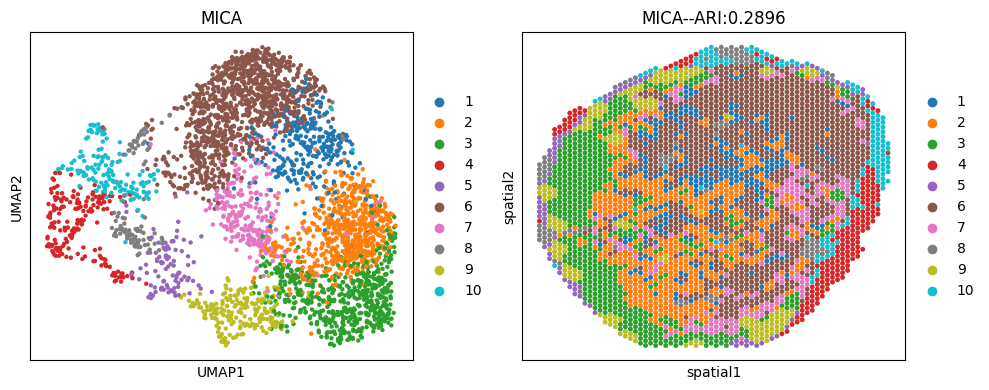

In [8]:
adata_plot = adata_rna.copy()
adata_plot.obsm["MICA"] = output["MICA"].copy()

clustering(
    adata_plot,
    key="MICA",
    add_key="MICA_cluster",
    n_clusters=n_clusters,
    method=CLUSTER_METHOD,
    use_pca=USE_PCA_FOR_CLUSTERING,
)

print("Clustering finished.")

ari_score = None

if ground_truth is not None:
    adata_plot.obs["Ground_Truth"] = pd.Series(ground_truth).astype(str).values
    pred_labels = pd.Series(adata_plot.obs["MICA_cluster"], index=adata_plot.obs.index)
    true_labels = pd.Series(adata_plot.obs["Ground_Truth"], index=adata_plot.obs.index)
    ari_score = evaluate_ari(true_labels, pred_labels)

    print("ARI evaluation finished.")
else:
    print("Ground truth not available, so ARI evaluation is skipped.")

plot_results(adata_plot, ari_score=ari_score)